In [70]:
import pandas as pd
import numpy as np

In [71]:
#Part   A
#Q1
df = pd.read_csv('/content/Dataset 2.csv')
display(df.head())


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [72]:
# Q2
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 750
Number of columns: 10


In [73]:
#Q3
print(df.columns)

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [74]:
#Q4
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   UserID               750 non-null    int64 
 1   Age                  750 non-null    int64 
 2   Gender               750 non-null    object
 3   SubscriptionType     750 non-null    object
 4   WatchHoursPerWeek    750 non-null    int64 
 5   DevicesUsed          750 non-null    int64 
 6   FavoriteGenre        750 non-null    object
 7   AdClicks             750 non-null    int64 
 8   MonthlySpend         750 non-null    int64 
 9   SubscriptionRenewed  750 non-null    object
dtypes: int64(6), object(4)
memory usage: 58.7+ KB


In [75]:
#Q5
print("Does the dataset have any missing values?", df.isnull().values.any())

Does the dataset have any missing values? False


In [76]:
#Part B
#Q6
average_age = df['Age'].mean()
print(f"Average age of users: {average_age:.2f} years")

Average age of users: 41.82 years


In [77]:
#Q7
average_watch_hours = df['WatchHoursPerWeek'].mean()
print(f"Average watch hours per week: {average_watch_hours:.2f} hours")

Average watch hours per week: 14.24 hours


In [78]:
#Q8
average_monthly_spending = df['MonthlySpend'].mean()
print(f"Average monthly spending of users: ${average_monthly_spending:.2f}")

Average monthly spending of users: $689.91


In [79]:
#Q9
subscription_counts = df['SubscriptionType'].value_counts()
print("Number of users in each subscription category:\n", subscription_counts)

Number of users in each subscription category:
 SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [80]:
#Q10
renewal_counts = df['SubscriptionRenewed'].value_counts(normalize=True) * 100
print("Percentage of users who renewed their subscriptions:\n", renewal_counts)

Percentage of users who renewed their subscriptions:
 SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


In [81]:
#Part C
#Q11
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,UserID,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi,SubscriptionRenewed_Yes
0,1001,22,23,5,13,353,False,False,False,True,False,False,False,False,False
1,1002,55,9,4,14,317,True,False,False,False,True,False,False,False,True
2,1003,49,8,3,16,309,True,False,False,True,False,False,False,False,False
3,1004,39,19,5,45,833,False,True,False,False,True,False,False,False,True
4,1005,38,23,5,24,804,False,True,False,False,False,False,False,True,True


In [82]:
#Q12
X = df_encoded.drop(['SubscriptionRenewed_Yes'], axis=1)
y = df_encoded['SubscriptionRenewed_Yes']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures (X) head:\n", X.head())
print("\nTarget (y) head:\n", y.head())

Features (X) shape: (750, 14)
Target (y) shape: (750,)

Features (X) head:
    UserID  Age  WatchHoursPerWeek  DevicesUsed  AdClicks  MonthlySpend  \
0    1001   22                 23            5        13           353   
1    1002   55                  9            4        14           317   
2    1003   49                  8            3        16           309   
3    1004   39                 19            5        45           833   
4    1005   38                 23            5        24           804   

   Gender_Male  SubscriptionType_Premium  SubscriptionType_VIP  \
0        False                     False                 False   
1         True                     False                 False   
2         True                     False                 False   
3        False                      True                 False   
4        False                      True                 False   

   FavoriteGenre_Comedy  FavoriteGenre_Drama  FavoriteGenre_Horror  \
0           

In [83]:
#Q13
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (600, 14)
X_test shape: (150, 14)
y_train shape: (600,)
y_test shape: (150,)


In [84]:
#Part D
#Q14
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


In [85]:
#Q15
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")

Decision Tree Model Accuracy: 0.5533


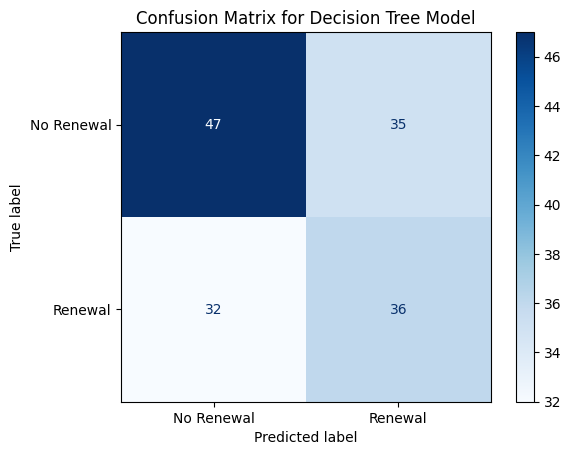

Interpretation of Confusion Matrix:
True Negatives (TN): 47 (Correctly predicted 'No Renewal')
False Positives (FP): 35 (Incorrectly predicted 'Renewal' when it was 'No Renewal')
False Negatives (FN): 32 (Incorrectly predicted 'No Renewal' when it was 'Renewal')
True Positives (TP): 36 (Correctly predicted 'Renewal')


In [86]:
#Q16
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Renewal', 'Renewal'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree Model')
plt.show()

print("Interpretation of Confusion Matrix:")
print(f"True Negatives (TN): {cm_dt[0, 0]} (Correctly predicted 'No Renewal')")
print(f"False Positives (FP): {cm_dt[0, 1]} (Incorrectly predicted 'Renewal' when it was 'No Renewal')")
print(f"False Negatives (FN): {cm_dt[1, 0]} (Incorrectly predicted 'No Renewal' when it was 'Renewal')")
print(f"True Positives (TP): {cm_dt[1, 1]} (Correctly predicted 'Renewal')")

In [87]:
# Part E
# Q17
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier with K=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN Classifier with K=5 trained successfully!")

KNN Classifier with K=5 trained successfully!


In [88]:
# Q18
from sklearn.metrics import accuracy_score

# Make predictions on the test set using KNN model
y_pred_knn = knn_model.predict(X_test)

# Calculate accuracy for KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Model Accuracy (K=5): {accuracy_knn:.4f}")

# Compare with Decision Tree Model Accuracy
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")

if accuracy_knn > accuracy_dt:
    print("KNN model performed better than the Decision Tree model.")
elif accuracy_knn < accuracy_dt:
    print("Decision Tree model performed better than the KNN model.")
else:
    print("Both models performed equally.")


KNN Model Accuracy (K=5): 0.6000
Decision Tree Model Accuracy: 0.5533
KNN model performed better than the Decision Tree model.


In [89]:
#Part F
#Q19
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define features (X_reg) and target (y_reg) for regression
X_reg = df_encoded.drop(['UserID', 'MonthlySpend', 'SubscriptionRenewed_Yes'], axis=1)
y_reg = df_encoded['MonthlySpend']

# Split the data into training and testing sets for regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_reg_train, y_reg_train)

print("Linear Regression model trained successfully!")
print(f"Model Coefficients: {linear_regression_model.coef_}")
print(f"Model Intercept: {linear_regression_model.intercept_}")

Linear Regression model trained successfully!
Model Coefficients: [-9.16086955e-02  5.20968593e+00 -1.92039989e-01  1.60517208e-01
  1.09954938e+00  4.01269522e+02  1.00818716e+03 -3.41191337e+00
 -1.02016728e+01  3.62774164e+00 -2.44849776e+00 -3.12957530e+00]
Model Intercept: 296.8448582355831


In [91]:
#Q20
import pandas as pd

# Create a new user's data (ensure it matches the feature columns of X_reg)
# Example: Age=30, WatchHoursPerWeek=15, DevicesUsed=3, AdClicks=20,
#          Gender=Female, SubscriptionType=Premium, FavoriteGenre=Comedy

new_user_data = pd.DataFrame({
    'Age': [30],
    'WatchHoursPerWeek': [15],
    'DevicesUsed': [3],
    'AdClicks': [20],
    'Gender_Male': [False], # Female
    'SubscriptionType_Premium': [True], # Premium
    'SubscriptionType_VIP': [False],
    'FavoriteGenre_Comedy': [True],
    'FavoriteGenre_Drama': [False],
    'FavoriteGenre_Horror': [False],
    'FavoriteGenre_Romance': [False],
    'FavoriteGenre_Sci-Fi': [False]
})

# Ensure column order matches training data if not using feature names directly
# For simplicity, we assume the dummy variable creation maintains consistent order if applied on a similar structure.
# However, it's safer to re-create dummies or ensure the column order.
# For this example, we'll assume the direct DataFrame creation is correctly ordered.

# Make a prediction for the new user
predicted_spending = linear_regression_model.predict(new_user_data)

print(f"Predicted Monthly Spending for the new user: ${predicted_spending[0]:.2f}")

print("\nInterpretation:")
print("The predicted monthly spending for a new user with these characteristics is approximately ")
print(f"${predicted_spending[0]:.2f}. This value is derived from the linear relationship ")
print("learned by the model between the user's features (age, watch hours, ad clicks, etc.) and their monthly spending.")
print("The coefficients of the model indicate the impact of each feature on the monthly spending. ")
print("For example, a positive coefficient for 'WatchHoursPerWeek' would suggest that more watch hours ")
print("tend to correlate with higher monthly spending, all else being equal.")

Predicted Monthly Spending for the new user: $772.73

Interpretation:
The predicted monthly spending for a new user with these characteristics is approximately 
$772.73. This value is derived from the linear relationship 
learned by the model between the user's features (age, watch hours, ad clicks, etc.) and their monthly spending.
The coefficients of the model indicate the impact of each feature on the monthly spending. 
For example, a positive coefficient for 'WatchHoursPerWeek' would suggest that more watch hours 
tend to correlate with higher monthly spending, all else being equal.
